# Task 1 - MLP classifier

Same Frangieh preprocessing, features, labels and splits as the XGBoost notebook. The only change is the classifier.

Package caches in a writable temporary directory before importing Scanpy-related packages. Matplotlib/Numba cache writes can otherwise fail or slow down imports. 

In [1]:
from pathlib import Path
import os
import tempfile
import sys
import json

cache_dir = Path(tempfile.gettempdir()) / "sc-course-2026-cache"
(cache_dir / "matplotlib").mkdir(parents=True, exist_ok=True)
(cache_dir / "numba").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(cache_dir / "matplotlib"))
os.environ.setdefault("NUMBA_CACHE_DIR", str(cache_dir / "numba"))
os.environ.setdefault("XDG_CACHE_HOME", str(cache_dir))

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp

import torch
import torch.nn as nn
from tqdm.auto import tqdm

from xgboost import XGBClassifier
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.metrics import balanced_accuracy_score, classification_report

# Resolve paths the same way whether Jupyter starts in the repository root or notebooks/.
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root / "src"))
from preprocessing import preprocess
from models import fit_xgb

seed = 123
np.random.seed(seed)
torch.manual_seed(seed)

sns.set_theme(style="whitegrid")
sc.settings.verbosity = 1

modelling input path. `data/dataset_hv.h5ad` is the cached preprocessed dataset (216,431 QC-passing cells x 1,011 genes = 1,000 highly variable genes plus the paper marker genes; CP10K + log1p; PCA(50)/neighbours/UMAP already stored). If it is absent, build it and the shared Parquet inputs with `python src/prepare_data.py`.

In [2]:
data_dir = repo_root / "data"
rna_path = data_dir / "frangieh" / "rna.h5ad"
adata_hv_path = data_dir / "dataset_hv.h5ad"

print(rna_path.resolve())
print(adata_hv_path.resolve())
print("cache present:", adata_hv_path.exists())

/Users/leventetn/Documents/Master/scMulti/SingleCellCourse_TA-LTN/data/frangieh/rna.h5ad
/Users/leventetn/Documents/Master/scMulti/SingleCellCourse_TA-LTN/data/dataset_hv.h5ad
cache present: True


loading the shared modelling dataset. If it is missing, run `python src/prepare_data.py` once from the repository root. Keeping preprocessing in one script ensures that all four notebooks use the same cells, labels and genes.

In [ ]:
# All notebooks use the same cache. Build it once instead of maintaining a
# second, slightly different preprocessing pipeline inside this notebook.
if not adata_hv_path.exists():
    raise FileNotFoundError(
        f"{adata_hv_path} is missing. Run: python src/prepare_data.py"
    )
adata_hv = sc.read_h5ad(adata_hv_path)

# The cached file stores the treatment condition as obs['condition'].
if 'perturbation_2' not in adata_hv.obs:
    adata_hv.obs['perturbation_2'] = adata_hv.obs['condition'].astype(str).astype('category')

# the dataset is sparse
adata_hv.X = sp.csr_matrix(adata_hv.X)

adata_hv

AnnData object with n_obs × n_vars = 216431 × 1011
    obs: 'cell_name', 'condition', 'perturbation', 'pert_label', 'guide_id', 'MOI', 'n_targeting_guides', 'n_guide_tokens', 'ncounts', 'ngenes', 'percent_mito', 'nperts', 'qc_pass', 'is_single_pert', 'is_clean_control', 'perturbation_2'
    var: 'highly_variable', 'paper_marker', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'neighbors', 'pca', 'pseudobulk_provenance', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'counts', None (.X)

converting the treatment condition in `perturbation_2` into integer class labels for scikit-learn, XGBoost and PyTorch. Printing the class order and the number of cells per condition so class imbalance is visible before training

In [4]:
le = preprocessing.LabelEncoder()
le.fit(adata_hv.obs['perturbation_2'])
adata_hv.obs['label'] = le.transform(adata_hv.obs['perturbation_2'])

classes = le.classes_
y = adata_hv.obs['label'].to_numpy(dtype=np.int64)

print(classes)
display(adata_hv.obs['perturbation_2'].value_counts().to_frame('n_cells'))

['Co-culture' 'Control' 'IFNγ']


,n_cells
perturbation_2,
IFNγ,86994
Co-culture,72398
Control,57039


## XGBoost reference

This reference model repeats the Task 1 XGBoost setup on the same features and labels. Stratified folds keep the treatment-condition proportions similar in every split, and balanced accuracy is used because it weighs each class equally. Cross-validation is kept single-process here to avoid copying the AnnData matrix into several worker processes.

In [5]:
pipe = make_pipeline(
    XGBClassifier(n_estimators=6, max_depth=6, learning_rate=0.05, objective='multi:softprob', num_class=len(classes), tree_method='hist', n_jobs=2)
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
xgb_cv = cross_val_score(pipe, adata_hv.X, y, cv=skf, scoring="balanced_accuracy", n_jobs=1)
print(f"XGBoost balanced accuracy: {xgb_cv.mean():.3f} +/- {xgb_cv.std():.3f}")

XGBoost balanced accuracy: 0.971 +/- 0.001


## MLP

PyTorch pieces for the MLP: device selection, the neural-network architecture, sparse-safe mini-batch conversion, shuffled batch iteration, training with cross-entropy loss and batched prediction

In [ ]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = get_device()
print(device)


class MLPClassifier(nn.Module):
    def __init__(self, n_features, n_classes, hidden=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def make_batch(X, y_values, idx, device):
    # keep the full expression matrix sparse
    X_batch = X[idx].toarray()

    X_batch = torch.as_tensor(X_batch, dtype=torch.float32, device=device)
    y_batch = None if y_values is None else torch.as_tensor(y_values[idx], dtype=torch.long, device=device)
    return X_batch, y_batch


def batches(indices, batch_size, shuffle=True, seed=seed):
    indices = np.asarray(indices)
    if shuffle:
        rng = np.random.default_rng(seed)
        indices = rng.permutation(indices)
    for start in range(0, len(indices), batch_size):
        yield indices[start:start + batch_size]


def fit_mlp(X, y, train_idx, valid_idx=None, hidden=128, dropout=0.2, n_epochs=8, batch_size=4096, lr=1e-3, weight_decay=1e-4):
    torch.manual_seed(seed)
    model = MLPClassifier(X.shape[1], len(np.unique(y)), hidden=hidden, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    history = []
    for epoch in tqdm(range(n_epochs)):
        model.train()
        train_loss = 0.0
        n_seen = 0
        for batch_idx in batches(train_idx, batch_size, shuffle=True, seed=seed + epoch):
            X_batch, y_batch = make_batch(X, y, batch_idx, device)
            opt.zero_grad()
            loss = loss_fn(model(X_batch), y_batch)
            loss.backward()
            opt.step()

            train_loss += loss.item() * len(batch_idx)
            n_seen += len(batch_idx)

        row = {"epoch": epoch + 1, "train_loss": train_loss / n_seen}
        if valid_idx is not None:
            pred, _ = predict_mlp(model, X, valid_idx, batch_size=batch_size)
            row["valid_balanced_accuracy"] = balanced_accuracy_score(y[valid_idx], pred)
        history.append(row)

    return model, pd.DataFrame(history)


@torch.no_grad()
def predict_mlp(model, X, indices, batch_size=8192):
    model.eval()
    pred_all = []
    proba_all = []
    for batch_idx in batches(indices, batch_size, shuffle=False):
        X_batch, _ = make_batch(X, None, batch_idx, device)
        logits = model(X_batch)
        proba = torch.softmax(logits, dim=1)
        pred_all.append(proba.argmax(dim=1).cpu().numpy())
        proba_all.append(proba.cpu().numpy())
    return np.concatenate(pred_all), np.vstack(proba_all)

cpu


This cell evaluates the MLP with the same stratified 5-fold splits used for the XGBoost reference. Each fold trains on four fifths of the cells, predicts the held-out fifth and stores balanced accuracy for a final mean and standard deviation.

In [7]:
mlp_cv = []

for fold, (train_idx, test_idx) in enumerate(skf.split(adata_hv.X, y), start=1):
    model, hist = fit_mlp(adata_hv.X, y, train_idx, valid_idx=test_idx, n_epochs=8)
    pred, _ = predict_mlp(model, adata_hv.X, test_idx)
    score = balanced_accuracy_score(y[test_idx], pred)
    mlp_cv.append(score)
    print(f"fold {fold}: {score:.3f}")

mlp_cv = np.asarray(mlp_cv)
print(f"MLP balanced accuracy: {mlp_cv.mean():.3f} +/- {mlp_cv.std():.3f}")

fold 1: 0.986
fold 2: 0.985
fold 3: 0.984
fold 4: 0.986
fold 5: 0.984
MLP balanced accuracy: 0.985 +/- 0.001



100%|##########| 8/8 [00:09<00:00,  1.25s/it]

100%|##########| 8/8 [00:10<00:00,  1.36s/it]

100%|##########| 8/8 [00:12<00:00,  1.58s/it]

100%|##########| 8/8 [00:11<00:00,  1.46s/it]

100%|##########| 8/8 [00:07<00:00,  1.00it/s]


## One split for feature importance

`fit_xgb` uses this same stratified 80/20 split internally.

training one final XGBoost model and one final MLP on a stratified 80/20 train/test split. The held-out split is reused for the detailed classification report and for the feature-importance comparison in the next section.

In [8]:
train_idx, test_idx = train_test_split(
    np.arange(adata_hv.n_obs),
    test_size=0.2,
    stratify=y,
    random_state=seed,
)

bst, xgb_holdout_bal_acc, X_train_xgb, y_train_xgb = fit_xgb(adata_hv, .2, 6, 6)
print(f"XGBoost holdout balanced accuracy: {xgb_holdout_bal_acc:.3f}")

mlp, mlp_hist = fit_mlp(adata_hv.X, y, train_idx, valid_idx=test_idx, n_epochs=12)
mlp_pred, mlp_proba = predict_mlp(mlp, adata_hv.X, test_idx)
mlp_holdout_bal_acc = balanced_accuracy_score(y[test_idx], mlp_pred)
print(f"MLP holdout balanced accuracy: {mlp_holdout_bal_acc:.3f}")
print()
print(classification_report(y[test_idx], mlp_pred, target_names=classes, digits=3))

display(mlp_hist.tail())

XGBoost holdout balanced accuracy: 0.971
MLP holdout balanced accuracy: 0.987

              precision    recall  f1-score   support

  Co-culture      0.994     0.993     0.993     14480
     Control      0.962     0.992     0.976     11408
        IFNγ      0.994     0.975     0.985     17399

    accuracy                          0.985     43287
   macro avg      0.983     0.987     0.985     43287
weighted avg      0.986     0.985     0.985     43287




100%|##########| 12/12 [00:15<00:00,  1.31s/it]


,epoch,train_loss,valid_balanced_accuracy
7,8,0.042393,0.985668
8,9,0.040828,0.985872
9,10,0.039838,0.985780
10,11,0.038142,0.985388
11,12,0.036715,0.986546


## Gene importance

XGBoost uses its built-in split-count importance. The MLP uses absolute gradient times input on the held-out cells.

Computing one gene-importance table for both models. XGBoost reports how often each gene is used in tree splits; the MLP score is gradient times input, averaged over held-out cells, which estimates how strongly each input gene contributes to the model's true-class logit.

In [9]:
def gradient_x_input_importance(model, X, y, indices, max_cells=10_000, batch_size=2048):
    model.eval()
    rng = np.random.default_rng(seed)
    indices = np.asarray(indices)
    if len(indices) > max_cells:
        indices = np.sort(rng.choice(indices, max_cells, replace=False))

    importance = np.zeros(X.shape[1], dtype=np.float64)
    n_seen = 0

    for batch_idx in batches(indices, batch_size, shuffle=False):
        X_batch, y_batch = make_batch(X, y, batch_idx, device)
        X_batch.requires_grad_(True)

        model.zero_grad(set_to_none=True)
        logits = model(X_batch)
        selected_logits = logits.gather(1, y_batch[:, None]).sum()
        selected_logits.backward()

        batch_importance = (X_batch.grad * X_batch).abs().detach().cpu().numpy().sum(axis=0)
        importance += batch_importance
        n_seen += X_batch.shape[0]

    return importance / n_seen


mlp_importance = gradient_x_input_importance(mlp, adata_hv.X, y, test_idx)

mlp_imp = pd.DataFrame({
    "gene": adata_hv.var_names,
    "mlp_grad_x_input": mlp_importance,
})

xgb_gene_names = getattr(bst, "feature_names_in_", adata_hv.var_names)

xgb_imp = pd.DataFrame({
    "gene": xgb_gene_names,
    "xgb_importance": bst.feature_importances_,
})

importance = xgb_imp.merge(mlp_imp, on="gene", how="outer").fillna(0)
importance["xgb_rank"] = importance["xgb_importance"].rank(ascending=False, method="min")
importance["mlp_rank"] = importance["mlp_grad_x_input"].rank(ascending=False, method="min")
importance["best_rank"] = importance[["xgb_rank", "mlp_rank"]].min(axis=1)

display(importance.sort_values("mlp_grad_x_input", ascending=False).head(20))
display(importance.sort_values("xgb_importance", ascending=False).head(20))

,gene,xgb_importance,mlp_grad_x_input,xgb_rank,mlp_rank,best_rank
812,PFN1,0.140187,1.835722,2.0,1.0,1.0
556,HLA-B,0.080374,0.951776,3.0,2.0,2.0
362,CD74,0.157009,0.873741,1.0,3.0,1.0
487,FN1,0.048598,0.770583,6.0,4.0,4.0
508,GBP1,0.079439,0.768599,4.0,5.0,4.0
573,IDO1,0.059813,0.633943,5.0,6.0,5.0
995,WARS,0.034579,0.541956,8.0,7.0,7.0
949,TFPI2,0.000000,0.514897,106.0,8.0,8.0
739,MT2A,0.005607,0.481009,28.0,9.0,9.0
829,PMEPA1,0.045794,0.438520,7.0,10.0,7.0


,gene,xgb_importance,mlp_grad_x_input,xgb_rank,mlp_rank,best_rank
362,CD74,0.157009,0.873741,1.0,3.0,1.0
812,PFN1,0.140187,1.835722,2.0,1.0,1.0
556,HLA-B,0.080374,0.951776,3.0,2.0,2.0
508,GBP1,0.079439,0.768599,4.0,5.0,4.0
573,IDO1,0.059813,0.633943,5.0,6.0,5.0
487,FN1,0.048598,0.770583,6.0,4.0,4.0
829,PMEPA1,0.045794,0.438520,7.0,10.0,7.0
995,WARS,0.034579,0.541956,8.0,7.0,7.0
844,PTGES,0.020561,0.337901,9.0,14.0,9.0
640,LAP3,0.020561,0.244173,9.0,22.0,9.0


Rescaling the XGBoost and MLP importance columns separately and plots the top-ranked genes in one bar chart. The scaling makes the two different importance units comparable visually, but not numerically identical!!!

<cell>:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


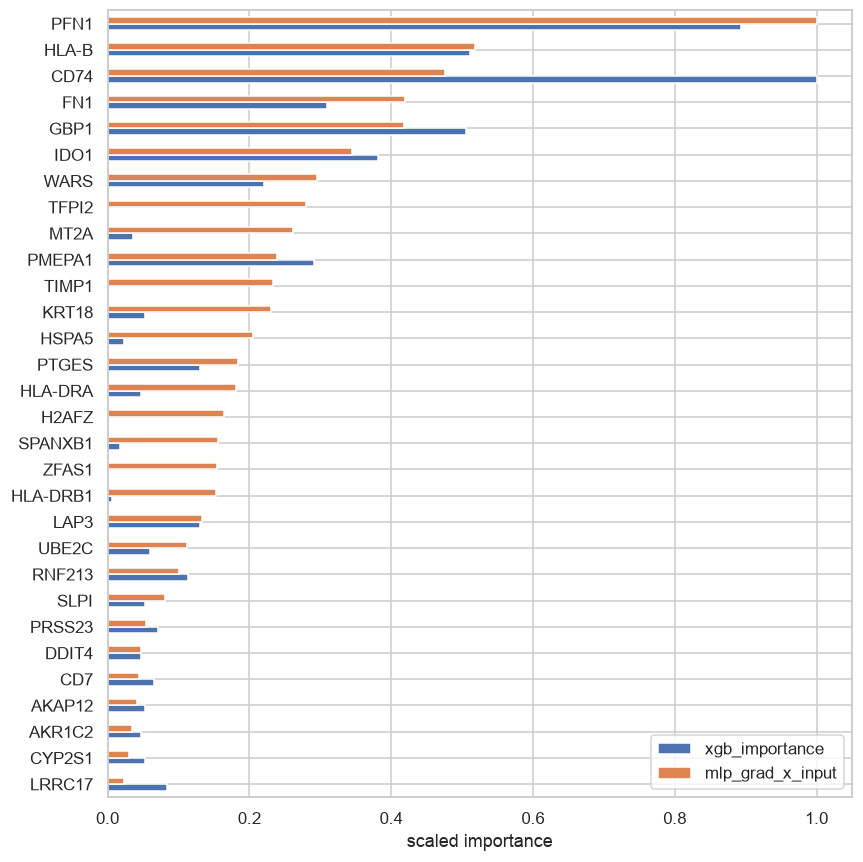

In [10]:
plot_df = (
    importance.sort_values("best_rank")
    .head(30)
    .set_index("gene")[["xgb_importance", "mlp_grad_x_input"]]
)

plot_df = plot_df / plot_df.max(axis=0)

ax = plot_df.sort_values("mlp_grad_x_input").plot(kind="barh", figsize=(8, 8))
ax.set_xlabel("scaled importance")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Vizualizing the strongest MLP genes on the stored UMAP embedding, together with the treatment labels. whether highly ranked genes correspond to visible condition-specific expression patterns

/Users/leventetn/.claude-science/conda/envs/sc-course/lib/python3.12/site-packages/scanpy/plotting/_utils.py:393: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/leventetn/.claude-science/conda/envs/sc-course/lib/python3.12/site-packages/scanpy/plotting/_utils.py:393: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


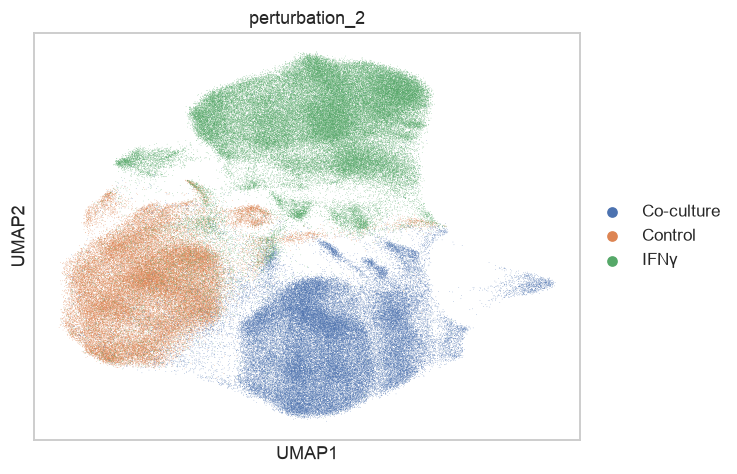

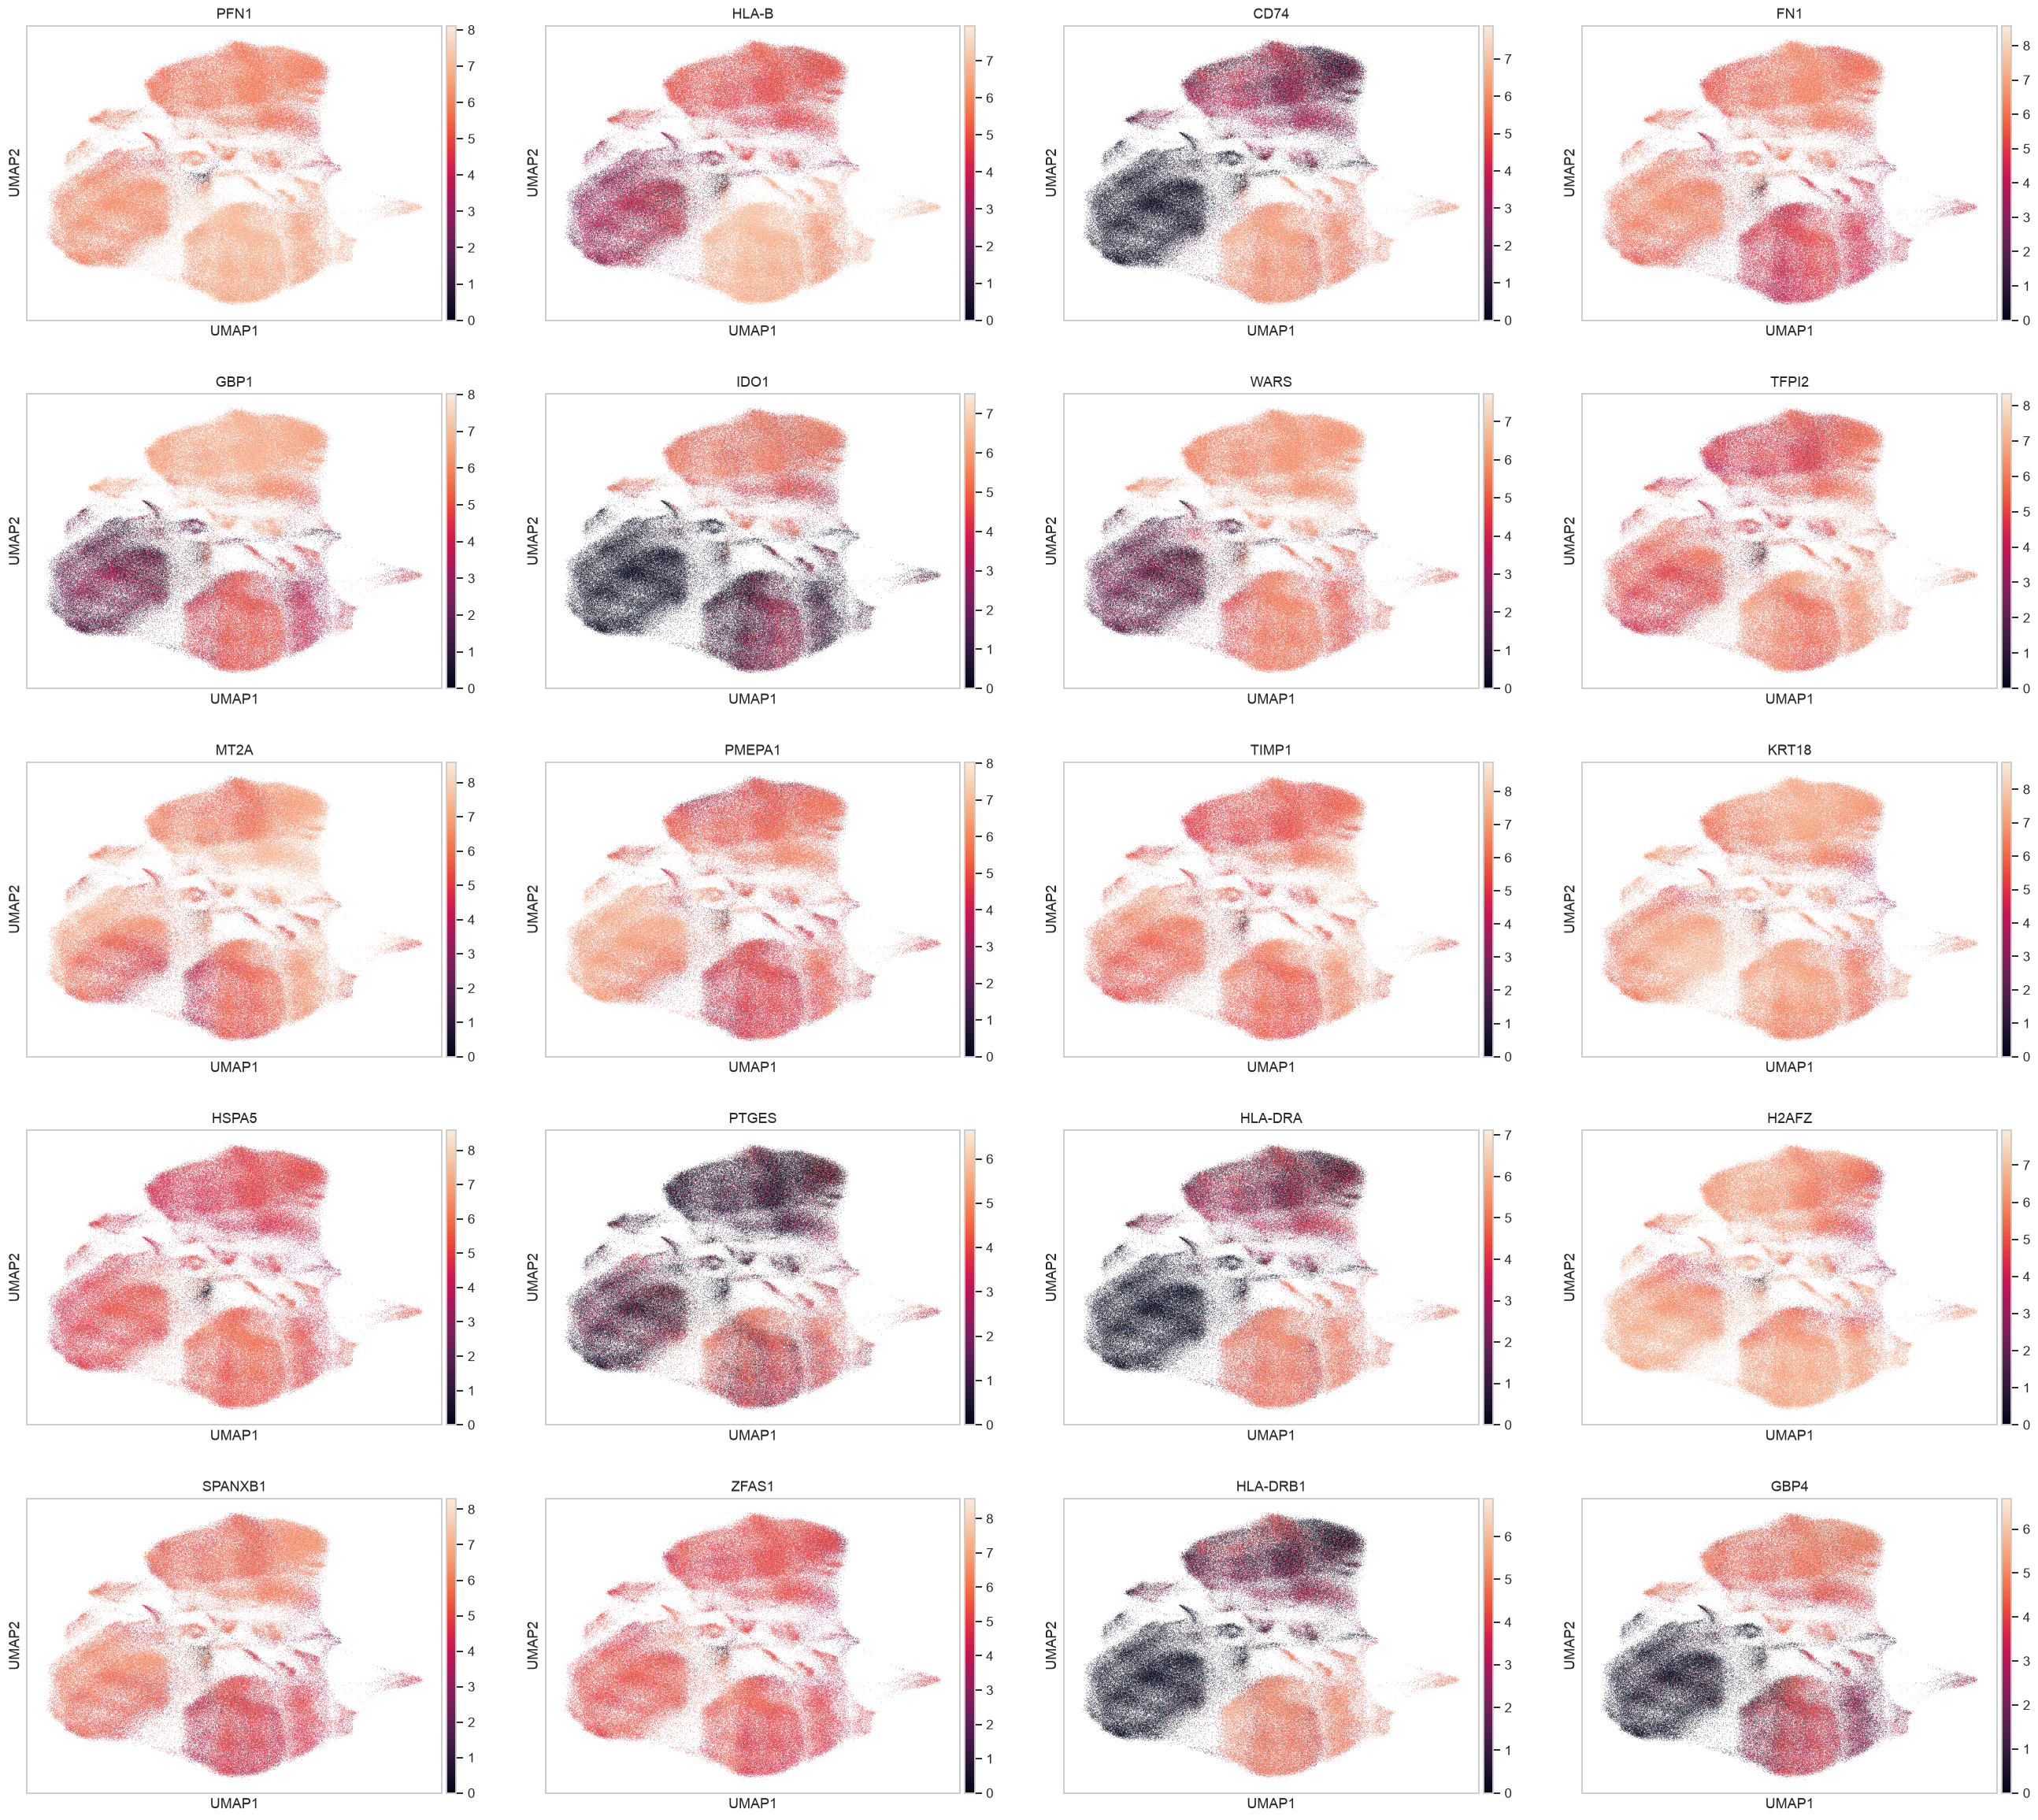

In [11]:
top_mlp_genes = importance.sort_values("mlp_grad_x_input", ascending=False).head(20)["gene"].tolist()

if "X_umap" in adata_hv.obsm:
    sc.pl.umap(adata_hv, color=['perturbation_2'])
    sc.pl.umap(adata_hv, color=top_mlp_genes)
else:
    print("UMAP is not stored in adata_hv. Run PCA/neighbors/UMAP first if you want these plots.")

## Recorded metrics

This cell writes the cross-validation and hold-out numbers produced above to `data/task1_mlp_notebook_metrics.json` so that the companion notebook `task1_feature_importance_cv.ipynb` and the summary tables read the same values rather than re-deriving them.

In [12]:
metrics = {
    "n_cells": int(adata_hv.n_obs),
    "n_genes": int(adata_hv.n_vars),
    "classes": [str(c) for c in classes],
    "class_counts": {str(k): int(v) for k, v in adata_hv.obs["perturbation_2"].value_counts().items()},
    "cv_folds": 5,
    "cv_seed": seed,
    "xgb_n_estimators": 6,
    "xgb_cv_balanced_accuracy": [float(v) for v in xgb_cv],
    "xgb_cv_mean": float(xgb_cv.mean()),
    "xgb_cv_sd": float(xgb_cv.std()),
    "mlp_cv_balanced_accuracy": [float(v) for v in mlp_cv],
    "mlp_cv_mean": float(mlp_cv.mean()),
    "mlp_cv_sd": float(mlp_cv.std()),
    "xgb_holdout_balanced_accuracy": float(xgb_holdout_bal_acc),
    "mlp_holdout_balanced_accuracy": float(mlp_holdout_bal_acc),
}

with open(data_dir / "task1_mlp_notebook_metrics.json", "w") as fh:
    json.dump(metrics, fh, indent=2)

pd.Series(
    {
        "XGBoost (6 rounds) 5-fold": f"{xgb_cv.mean():.3f} +/- {xgb_cv.std():.3f}",
        "MLP (128-64-3) 5-fold": f"{mlp_cv.mean():.3f} +/- {mlp_cv.std():.3f}",
        "XGBoost 80/20 holdout": f"{xgb_holdout_bal_acc:.3f}",
        "MLP 80/20 holdout": f"{mlp_holdout_bal_acc:.3f}",
    },
    name="balanced accuracy",
).to_frame()

,balanced accuracy
XGBoost (6 rounds) 5-fold,0.971 +/- 0.001
MLP (128-64-3) 5-fold,0.985 +/- 0.001
XGBoost 80/20 holdout,0.971
MLP 80/20 holdout,0.987
